### Import

In [40]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

S = 50
LEVEL = "high"
SEED = 1

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
R, P_RT, K, K0, _, _, CRATE, DRATE = load_parameters(I, T, generation_data, S, LEVEL, SEED)
P_DA, P_PN = load_price_data(P_RT)
INEFF = 0.9

MYP = np.zeros((I, T, S)) ; MYM = np.zeros((I, T, S)) ; MZC = np.zeros((I, T, S)) ; MZD = np.zeros((I, T, S)) ; MDP = np.zeros((I, T, S)) ; MDM = np.zeros((I, T, S))  
R_max = np.zeros((I, T)) ; R_min = np.zeros((I, T)); R_avg = np.zeros((I, T))
for i, t in product(range(I), range(T)):
    R_max[i, t] = np.max(R[i, t, :])
    R_min[i, t] = np.min(R[i, t, :])
    R_avg[i, t] = np.mean(R[i, t, :])
    
    for s in range(S): 
        MYP[i, t, s] = MDP[i, t, s] = R[i, t, s] + INEFF * DRATE[i]
        MZC[i, t, s] = min((1 / INEFF) * CRATE[i], R[i, t, s])
        MZD[i, t, s] = INEFF * DRATE[i]
        MYM[i, t, s] = MDM[i, t, s] = R_max[i, t] + INEFF * DRATE[i]
        # MYM[i, t, s] = MDM[i, t, s] = R[i, t, s] + INEFF * DRATE[i]

✅ 총 10개 파일을 불러왔습니다: 1033.csv, 1818.csv, 2502.csv, 2503.csv, 2634.csv, 2698.csv, 2816.csv, 545.csv, 665.csv, 690.csv
📊 데이터 Shape: I=10, T=24, S=50
✅ 시뮬레이션 초기화 완료: S=50, Randomness='high', Random Seed=1, M1=3679.70, M2=10215.24
   - 개별 K 값: [200. 200. 400. 600. 100. 600. 300. 200. 300. 200.]


### Individual Optimization

In [41]:
m1 = gp.Model("individual")
m1.setParam("MIPGap", 1e-3)

x_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")
yp_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
z_ind = m1.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
zc_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

# LDR 계수 변수들
zc0_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

# Big-M 관련 변수들    
phi1_ind = m1.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2_ind = m1.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") ; phi3_ind = m1.addVars(I, T, S, vtype=GRB.BINARY, name="phi3")

m1.update()

obj = (gp.quicksum(P_DA[t] * x_ind[i, t] for i in range(I) for t in range(T)) + 
       gp.quicksum((1/S) * (P_RT[t, s] * yp_ind[i, t, s] - P_PN[t, s] * ym_ind[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
m1.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    m1.addConstr(R[i, t, s] - x_ind[i, t] == yp_ind[i, t, s] - ym_ind[i, t, s] + zc_ind[i, t, s] - zd_ind[i, t, s])
    m1.addConstr(R[i, t, s] + zd_ind[i, t, s] >= yp_ind[i, t, s] + zc_ind[i, t, s])
    m1.addConstr(zd_ind[i, t, s]/INEFF <= z_ind[i, t, s])
    m1.addConstr(zd_ind[i, t, s]/INEFF <= DRATE[i])
    m1.addConstr(zc_ind[i, t, s]*INEFF <= K[i] - z_ind[i, t, s])
    m1.addConstr(zc_ind[i, t, s]*INEFF <= CRATE[i])
    m1.addConstr(z_ind[i, t, s] <= K[i])
    m1.addConstr(z_ind[i, t + 1, s] == z_ind[i, t, s] + INEFF * zc_ind[i, t, s] - zd_ind[i, t, s] / INEFF)

for i, s in product(range(I), range(S)): m1.addConstr(z_ind[i, 0, s] == K0[i])

for i, t, s in product(range(I), range(T), range(S)):
    m1.addConstr(zc_ind[i, t, s] == zc0_ind[i, t] + zc1_ind[i, t] * R[i, t, s] + zc2_ind[i, t] * (P_RT[t, s] - P_DA[t]))
    m1.addConstr(zd_ind[i, t, s] == zd0_ind[i, t] + zd1_ind[i, t] * R[i, t, s] + zd2_ind[i, t] * (P_RT[t, s] - P_DA[t]))

for i, t, s in product(range(I), range(T), range(S)):        
    m1.addConstr(ym_ind[i, t, s] <= MYM[i, t, s] * phi1_ind[i, t, s]) ; m1.addConstr(zc_ind[i, t, s] <= MZC[i, t, s] * (1 - phi1_ind[i, t, s]))
    m1.addConstr(zc_ind[i, t, s] <= MZC[i, t, s] * phi2_ind[i, t, s]) ; m1.addConstr(zd_ind[i, t, s] <= MZD[i, t, s] * (1 - phi2_ind[i, t, s]))

m1.optimize()

if m1.status == GRB.OPTIMAL:
    x_ind = np.array([[x_ind[i, t].X for t in range(T)] for i in range(I)])
    yp_ind = np.array([[[yp_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_ind = np.array([[[ym_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zc_ind = np.array([[[zc_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_ind = np.array([[[zd_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    z_ind = np.array([[[z_ind[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objval = m1.objVal
    phi1_ind = np.array([[[phi1_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; phi2_ind = np.array([[[phi2_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    
    zc0_ind = np.array([[zc0_ind[i, t].X for t in range(T)] for i in range(I)]) ; zc1_ind = np.array([[zc1_ind[i, t].X for t in range(T)] for i in range(I)]) ; zc2_ind = np.array([[zc2_ind[i, t].X for t in range(T)] for i in range(I)])
    zd0_ind = np.array([[zd0_ind[i, t].X for t in range(T)] for i in range(I)]) ; zd1_ind = np.array([[zd1_ind[i, t].X for t in range(T)] for i in range(I)]) ; zd2_ind = np.array([[zd2_ind[i, t].X for t in range(T)] for i in range(I)])
    OBJ_IND = m1.objVal

Set parameter MIPGap to value 0.001
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  0.001

Optimize a model with 168500 rows, 98180 columns and 402900 nonzeros
Model fingerprint: 0x6e90b70d
Variable types: 62180 continuous, 36000 integer (36000 binary)
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [9e-02, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 4e+03]
Found heuristic solution: objective 2908920.2266
Presolve removed 94512 rows and 48123 columns
Presolve time: 4.18s
Presolved: 73988 rows, 50057 columns, 219564 nonzeros
Found heuristic solution: objective 3026536.6039
Variable types: 36707 continuous, 13350 integer (13350 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal

In [42]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 70)
print("\n[Individual]") ; print(header)
for t in range(7, 22):
    # R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_ind[:, t].sum()
    # yp_avg = np.mean([yp_ind[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_ind[:, t, s].sum() for s in range(S)])
    # zc_avg = np.mean([zc_ind[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_ind[:, t, s].sum() for s in range(S)]) 
    # z_avg = np.mean([z_ind[:, t, s].sum() for s in range(S)])

    i=0
    R_avg = np.mean([R[i, t, s] for s in range(S)]) ; x_sum = x_ind[i, t]
    yp_avg = np.mean([yp_ind[i, t, s] for s in range(S)]) ; ym_avg = np.mean([ym_ind[i, t, s] for s in range(S)])
    zc_avg = np.mean([zc_ind[i, t, s] for s in range(S)]) ; zd_avg = np.mean([zd_ind[i, t, s] for s in range(S)]) 
    z_avg = np.mean([z_ind[i, t, s] for s in range(S)])

    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[Individual]
 t |        R        x       y+       y-       zc       zd        z
----------------------------------------------------------------------
 7 |   122.88     0.00    93.42     0.00    29.46     0.00     5.94
 8 |   277.56   181.44   122.98    26.86     0.00     0.00    32.46
 9 |   266.89   142.30   131.86     7.26     0.00     0.00    32.46
10 |   399.01   315.37   130.62    46.98     0.00     0.00    32.46
11 |   347.64   253.24   123.44    29.04     0.00     0.00    32.46
12 |   331.76   184.46   157.01     9.71     0.00     0.00    32.46
13 |   273.44     0.00   302.65     0.00     0.00    29.21    32.46
14 |   152.25     0.00   152.25     0.00     0.00     0.00     0.00
15 |   102.27    97.11    20.26    15.10     0.00     0.00     0.00
16 |   130.36    76.82    57.41     3.87     0.00     0.00     0.00
17 |   178.74   143.10    53.53    17.89     0.00     0.00     0.00
18 |   163.06   110.05    65.99    12.98     0.00     0.00     0.00
19 |    21.91    12.30    10.47

### Holistic Optimization (Linear Decision Rule + MILP - M)

In [43]:
m2 = gp.Model("holistic_MILP_M")
m2.setParam("MIPGap", 1e-5)
m2.setParam(GRB.Param.TimeLimit, 1500)
m2.setParam(GRB.Param.PoolSearchMode, 2)
m2.setParam(GRB.Param.PoolSolutions, 50)


x_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x") ; yp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
dp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")
z_hol = m2.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z") ; zc_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

phi1_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") 
phi3_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi3") ; phi4_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi4")
phi5_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi5") ; phi6_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi6") 

zc0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

m2.update()

obj = (gp.quicksum(P_DA[t] * x_hol[i, t] for i in range(I) for t in range(T)) + 
       gp.quicksum((1/S) * (P_RT[t, s] * yp_hol[i, t, s] - P_PN[t, s] * ym_hol[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
m2.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    m2.addConstr(R[i, t, s] - x_hol[i, t] == yp_hol[i, t, s] - ym_hol[i, t, s] + dp_hol[i, t, s] - dm_hol[i, t, s] + zc_hol[i, t, s] - zd_hol[i, t, s])
    m2.addConstr(R[i, t, s] + zd_hol[i, t, s] >= yp_hol[i, t, s] + dp_hol[i, t, s] + zc_hol[i, t, s])
    m2.addConstr(zd_hol[i, t, s]/INEFF <= z_hol[i, t, s])
    m2.addConstr(zd_hol[i, t, s]/INEFF <= DRATE[i])
    m2.addConstr(zc_hol[i, t, s]*INEFF <= K[i] - z_hol[i, t, s])
    m2.addConstr(zc_hol[i, t, s]*INEFF <= CRATE[i])
    m2.addConstr(z_hol[i, t, s] <= K[i])
    m2.addConstr(z_hol[i, t + 1, s] == z_hol[i, t, s] + INEFF * zc_hol[i, t, s] - zd_hol[i, t, s] / INEFF)
for i, s in product(range(I), range(S)): m2.addConstr(z_hol[i, 0, s] == K0[i])

balance_constraints = {}
for t, s in product(range(T), range(S)):
    balance_constraints[t, s] = m2.addConstr(gp.quicksum(dp_hol[i, t, s] for i in range(I)) == gp.quicksum(dm_hol[i, t, s] for i in range(I)), name=f"balance_{t}_{s}")

for i, t, s in product(range(I), range(T), range(S)):
    m2.addConstr(zc_hol[i, t, s] == zc0_hol[i, t] + zc1_hol[i, t] * R[i, t, s] + zc2_hol[i, t] * (P_RT[t, s] - P_DA[t]))
    m2.addConstr(zd_hol[i, t, s] == zd0_hol[i, t] + zd1_hol[i, t] * R[i, t, s] + zd2_hol[i, t] * (P_RT[t, s] - P_DA[t]))

for i, t, s in product(range(I), range(T), range(S)):
    m2.addConstr(dp_hol[i, t, s] <= MDP[i,t,s] * phi1_hol[i, t, s]) ; m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * (1 - phi1_hol[i, t, s]))
    m2.addConstr(zc_hol[i, t, s] <= MYP[i,t,s] * phi2_hol[i, t, s]) ; m2.addConstr(zd_hol[i, t, s] <= MYM[i,t,s] * (1 - phi2_hol[i, t, s]))
    m2.addConstr(ym_hol[i, t, s] <= MYM[i,t,s] * phi3_hol[i, t, s]) ; m2.addConstr(zc_hol[i, t, s] <= MZC[i,t,s] * (1 - phi3_hol[i, t, s]))
    m2.addConstr(ym_hol[i, t, s] <= MYM[i,t,s] * phi4_hol[i, t, s]) ; m2.addConstr(dp_hol[i, t, s] <= MDP[i,t,s] * (1 - phi4_hol[i, t, s]))
    m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * phi5_hol[i, t, s]) ; m2.addConstr(zc_hol[i, t, s] <= MZC[i,t,s] * (1 - phi5_hol[i, t, s]))
    m2.addConstr(yp_hol[i, t, s] <= MYP[i,t,s] * phi6_hol[i, t, s]) ; m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * (1 - phi6_hol[i, t, s])) 

m2.optimize()

m2_node_data_list_np = []
if m2.status == GRB.OPTIMAL or m2.status == GRB.TIME_LIMIT:
    x_hol = np.array([[x_hol[i, t].X for t in range(T)] for i in range(I)])
    yp_hol = np.array([[[yp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_hol = np.array([[[ym_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    dp_hol = np.array([[[dp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_hol = np.array([[[dm_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zc_hol = np.array([[[zc_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_hol = np.array([[[zd_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    z_hol = np.array([[[z_hol[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objval = m2.objVal
    OBJ_HOL = m2.objVal
    zc0_hol = np.array([[zc0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc1_hol = np.array([[zc1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc2_hol = np.array([[zc2_hol[i, t].X for t in range(T)] for i in range(I)])
    zd0_hol = np.array([[zd0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd1_hol = np.array([[zd1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd2_hol = np.array([[zd2_hol[i, t].X for t in range(T)] for i in range(I)])

    sol_count = m2.SolCount
print(f"\n[Solution Pool] Found {sol_count} feasible solutions.")

# 1. phi 변수 이름 저장
all_phi_var_names = []
for phi_dict in [phi1_hol, phi2_hol, phi3_hol, phi4_hol, phi5_hol, phi6_hol]:
    for var in phi_dict.values():
        all_phi_var_names.append(var.VarName)

# 2. balance 제약 이름 저장
balance_constr_names = {}
for (t, s), constr in balance_constraints.items():
    balance_constr_names[t, s] = constr.ConstrName

print(f"Extracting duals by copying model {sol_count} times...")

m2_node_data_list_np = []

# 3. SolCount 만큼 반복
for i in range(sol_count):
    # 1. 원본 모델에서 i번째 솔루션 선택
    m2.setParam(GRB.Param.SolutionNumber, i)
    current_obj = m2.PoolObjVal

    # 2. 모델 복사
    m2_lp = m2.copy()

    # 3. LP 환경 설정 (옵션이지만 추천)
    m2_lp.setParam(GRB.Param.Presolve, 0)
    m2_lp.setParam(GRB.Param.DualReductions, 0)
    m2_lp.setParam(GRB.Param.Method, 1) 
    m2_lp.setParam(GRB.Param.LogToConsole, 0)

    # 4. phi 변수 continuous + 고정
    for var_name in all_phi_var_names:
        # 원본에서 i번째 솔루션 값
        orig_var = m2.getVarByName(var_name)
        sol_val = orig_var.Xn

        # 복사본에서 같은 이름의 변수 찾기
        lp_var = m2_lp.getVarByName(var_name)
        lp_var.VType = GRB.CONTINUOUS   # <-- 중요: MIP → LP
        lp_var.LB = sol_val
        lp_var.UB = sol_val

    m2_lp.update()

    # 5. LP 풀기
    m2_lp.optimize()

    if m2_lp.status == GRB.OPTIMAL:
        current_duals_np = np.zeros((T, S))
        for (t, s), cname in balance_constr_names.items():
            lp_constr = m2_lp.getConstrByName(cname)
            current_duals_np[t, s] = lp_constr.Pi   # 이제 Pi 사용 가능

        m2_node_data_list_np.append((current_obj, current_duals_np))

    else:
        print(f"Warning: LP copy re-solve failed for solution {i} (Status: {m2_lp.status})")

m2.setParam(GRB.Param.SolutionNumber, 0)


print(f"\n[Solution Pool Succeeded (Copy Method)]")
print(f"Total feasible solutions processed and stored: {len(m2_node_data_list_np)}")

Set parameter MIPGap to value 1e-05
Set parameter TimeLimit to value 1500
Set parameter PoolSearchMode to value 2
Set parameter PoolSolutions to value 50
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  1500
MIPGap  1e-05
PoolSolutions  50
PoolSearchMode  2

Optimize a model with 265700 rows, 158180 columns and 654900 nonzeros
Model fingerprint: 0xe32ed6f5
Variable types: 86180 continuous, 72000 integer (72000 binary)
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [9e-02, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 104172 rows and 27031 columns
Presolve time: 0.52s
Presolved: 161528 rows, 131149 columns, 444598 nonzeros
Variable types: 59149 continuous, 72000 integer (72000 binary)
F

In [44]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 90)
print("\n[HOLISTIC]") ; print(header)
for t in range(7, 22):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_hol[:, t].sum()
    yp_avg = np.mean([yp_hol[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_hol[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_hol[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_hol[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_hol[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_hol[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_hol[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[HOLISTIC]
 t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 7 |   579.32   272.90   125.98     2.31   227.58   227.58   182.75     0.00    19.89
 8 |  1370.46   948.75   203.00    40.77   524.50   524.50   259.48     0.00   184.36
 9 |  1596.55  1294.73   149.14    61.76   613.83   613.83   214.43     0.00   417.89
10 |  1694.56  1443.10   145.65    61.01   705.63   705.63   166.81     0.00   610.88
11 |  1935.49  1716.50   165.97    69.63   639.20   639.20   122.65     0.00   761.01
12 |  3080.82  2829.20   382.57   116.02   608.76   608.76     1.52    16.46   871.40
13 |  3856.14     0.00  4553.26     0.00     0.00     0.00     0.00   697.12   854.49
14 |  4174.33     0.00  4164.85     0.00     0.00     0.00     9.47     0.00    79.91
15 |  7058.53  7140.74   483.69   615.18  1847.65  1847.65    49.76     0.47    88.44
16 |  6114.74  5855.59   509.85   303

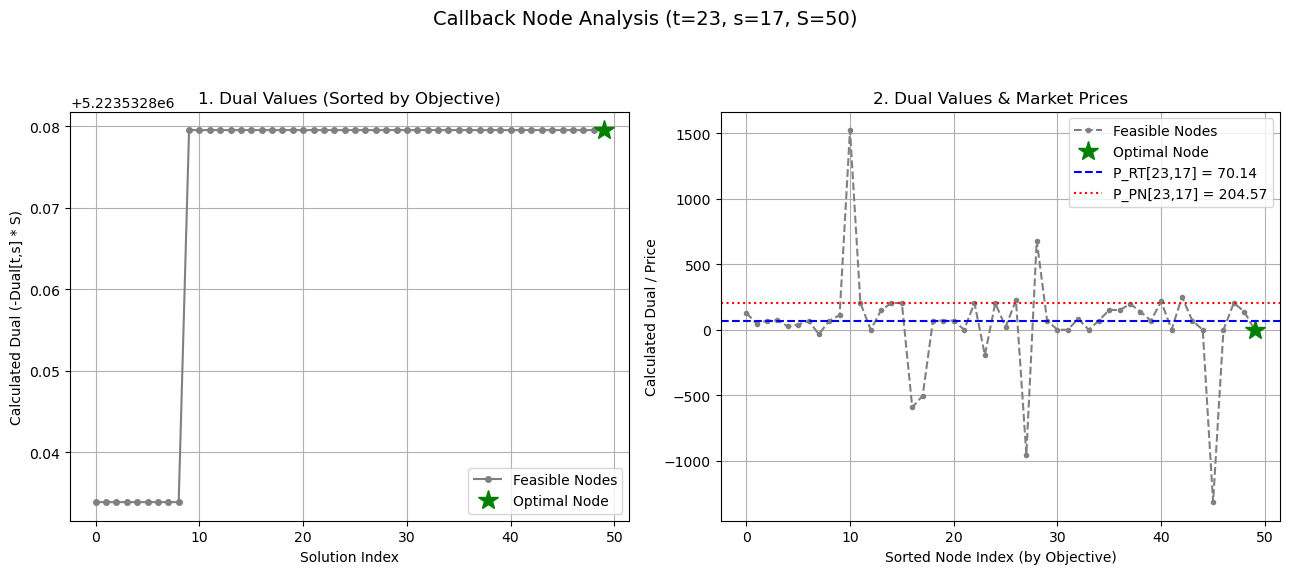

In [204]:
target_t = 23
target_s = 17

if len(m2_node_data_list_np) > 0:
    
    obj_values = []
    dual_plot_values_raw = []
    
    for obj, dual_array in m2_node_data_list_np:
        obj_values.append(obj)
        specific_dual_val = dual_array[target_t, target_s]
        dual_plot_values_raw.append(-specific_dual_val * S)

    combined_list = sorted(zip(obj_values, dual_plot_values_raw), key=lambda x: x[0])
     
    sorted_obj = [item[0] for item in combined_list]
    sorted_duals = [item[1] for item in combined_list]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(f'Callback Node Analysis (t={target_t}, s={target_s}, S={S})', fontsize=14)


    node_indices = np.arange(len(sorted_duals))
    ax1.plot(node_indices, sorted_obj,
            marker='o', linestyle='-', markersize=4, color='gray',
            label='Feasible Nodes')
    ax1.plot(node_indices[-1], sorted_obj[-1],
            marker='*', markersize=15, linestyle='none', color='green',
            label='Optimal Node')

    ax1.set_title('1. Dual Values (Sorted by Objective)')
    ax1.set_xlabel('Solution Index')
    ax1.set_ylabel(f'Calculated Dual (-Dual[t,s] * S)')
    ax1.legend()
    ax1.grid(True)


    ax2.plot(node_indices, sorted_duals, marker='.', linestyle='--', color='gray', label='Feasible Nodes')
    ax2.plot(node_indices[-1], sorted_duals[-1], marker='*', markersize=15, linestyle='none', color='green', label='Optimal Node')
    
    prt_val = P_RT[target_t, target_s]
    ppn_val = P_PN[target_t, target_s]
    
    ax2.axhline(y=prt_val, color='blue', linestyle='--', label=f'P_RT[{target_t},{target_s}] = {prt_val:.2f}')
    ax2.axhline(y=ppn_val, color='red', linestyle=':', label=f'P_PN[{target_t},{target_s}] = {ppn_val:.2f}')

    ax2.set_title('2. Dual Values & Market Prices')
    ax2.set_xlabel('Sorted Node Index (by Objective)')
    ax2.set_ylabel(f'Calculated Dual / Price')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print(f"\n[Plot Error] 저장된 노드 데이터가 없습니다. (m2_node_data_list_np is empty)")

### Holistic Optimization (Linear Decision Rule + MILP - U)

In [46]:
# UDP = np.zeros((I, T, S)) ; UDM = np.zeros((I, T, S))
# UYP = np.zeros((I, T, S)) ; UYM = np.zeros((I, T, S))
# UZC = np.zeros((I, T, S)) ; UZD = np.zeros((I, T, S))

# margin = 1.05
# for i, t, s in product(range(I), range(T), range(S)):
#     UDP[i, t, s] = dp_hol[i, t, s] * margin
#     UDM[i, t, s] = dm_hol[i, t, s] * margin
#     UYP[i, t, s] = yp_hol[i, t, s] * margin
#     UYM[i, t, s] = ym_hol[i, t, s] * margin
#     UZC[i, t, s] = zc_hol[i, t, s] * margin
#     UZD[i, t, s] = zd_hol[i, t, s] * margin
    
# # margin = 5
# # for i, t, s in product(range(I), range(T), range(S)):
# #     UDP[i, t, s] = dp_hol[i, t, s].X + margin
# #     UDM[i, t, s] = dm_hol[i, t, s].X + margin
# #     UYP[i, t, s] = yp_hol[i, t, s].X + margin
# #     UYM[i, t, s] = ym_hol[i, t, s].X + margin
# #     UZC[i, t, s] = zc_hol[i, t, s].X + margin
# #     UZD[i, t, s] = zd_hol[i, t, s].X + margin

In [47]:
# m3 = gp.Model("holistic_MILP_U")
# m3.setParam("MIPGap", 1e-5)
# m3.setParam(GRB.Param.TimeLimit, 1800)

# x_h = m3.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x") ; yp_h = m3.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_h = m3.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
# dp_h = m3.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm_h = m3.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")
# z_h = m3.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z") ; zc_h = m3.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_h = m3.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

# phi1_h = m3.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2_h = m3.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") 
# phi3_h = m3.addVars(I, T, S, vtype=GRB.BINARY, name="phi3") ; phi4_h = m3.addVars(I, T, S, vtype=GRB.BINARY, name="phi4")
# phi5_h = m3.addVars(I, T, S, vtype=GRB.BINARY, name="phi5") ; phi6_h = m3.addVars(I, T, S, vtype=GRB.BINARY, name="phi6") 

# zc0_h = m3.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_h = m3.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_h = m3.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
# zd0_h = m3.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_h = m3.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_h = m3.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

# m3.update()

# obj = (gp.quicksum(P_DA[t] * x_h[i, t] for i in range(I) for t in range(T)) + 
#        gp.quicksum((1/S) * (P_RT[t, s] * yp_h[i, t, s] - P_PN[t, s] * ym_h[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
# m3.setObjective(obj, GRB.MAXIMIZE)

# for i, t, s in product(range(I), range(T), range(S)):
#     m3.addConstr(R[i, t, s] - x_h[i, t] == yp_h[i, t, s] - ym_h[i, t, s] + dp_h[i, t, s] - dm_h[i, t, s] + zc_h[i, t, s] - zd_h[i, t, s])
#     m3.addConstr(R[i, t, s] + zd_h[i, t, s] >= yp_h[i, t, s] + dp_h[i, t, s] + zc_h[i, t, s])
#     m3.addConstr(zd_h[i, t, s]/INEFF <= z_h[i, t, s])
#     m3.addConstr(zd_h[i, t, s]/INEFF <= DRATE[i])
#     m3.addConstr(zc_h[i, t, s]*INEFF <= K[i] - z_h[i, t, s])
#     m3.addConstr(zc_h[i, t, s]*INEFF <= CRATE[i])
#     m3.addConstr(z_h[i, t, s] <= K[i])
#     m3.addConstr(z_h[i, t + 1, s] == z_h[i, t, s] + INEFF * zc_h[i, t, s] - zd_h[i, t, s] / INEFF)
# for i, s in product(range(I), range(S)): m3.addConstr(z_h[i, 0, s] == K0[i])

# for t, s in product(range(T), range(S)):
#     balance_constraints[t, s] = m3.addConstr(gp.quicksum(dp_h[i, t, s] for i in range(I)) == gp.quicksum(dm_h[i, t, s] for i in range(I)), name=f"balance_{t}_{s}")

# for i, t, s in product(range(I), range(T), range(S)):
#     m3.addConstr(zc_h[i, t, s] == zc0_h[i, t] + zc1_h[i, t] * R[i, t, s] + zc2_h[i, t] * (P_RT[t, s] - P_DA[t]))
#     m3.addConstr(zd_h[i, t, s] == zd0_h[i, t] + zd1_h[i, t] * R[i, t, s] + zd2_h[i, t] * (P_RT[t, s] - P_DA[t]))

# for i, t, s in product(range(I), range(T), range(S)):
#     m3.addConstr(dp_h[i, t, s] <= UDP[i,t,s] * phi1_h[i, t, s]) ; m3.addConstr(dm_h[i, t, s] <= UDM[i,t,s] * (1 - phi1_h[i, t, s]))
#     m3.addConstr(zc_h[i, t, s] <= UYP[i,t,s] * phi2_h[i, t, s]) ; m3.addConstr(zd_h[i, t, s] <= UYM[i,t,s] * (1 - phi2_h[i, t, s]))
#     m3.addConstr(ym_h[i, t, s] <= UYM[i,t,s] * phi3_h[i, t, s]) ; m3.addConstr(zc_h[i, t, s] <= UZC[i,t,s] * (1 - phi3_h[i, t, s]))
#     m3.addConstr(ym_h[i, t, s] <= UYM[i,t,s] * phi4_h[i, t, s]) ; m3.addConstr(dp_h[i, t, s] <= UDP[i,t,s] * (1 - phi4_h[i, t, s]))
#     m3.addConstr(dm_h[i, t, s] <= UDM[i,t,s] * phi5_h[i, t, s]) ; m3.addConstr(zc_h[i, t, s] <= UZC[i,t,s] * (1 - phi5_h[i, t, s]))
#     m3.addConstr(yp_h[i, t, s] <= UYP[i,t,s] * phi6_h[i, t, s]) ; m3.addConstr(dm_h[i, t, s] <= UDM[i,t,s] * (1 - phi6_h[i, t, s])) 

# m3.optimize()

# if m3.status == GRB.OPTIMAL:
#     print("✅ Optimal solution found.")
# elif m3.status == GRB.TIME_LIMIT and m3.SolCount > 0:
#     print("⏰ Time limit reached. Using best available solution.")
# else:
#     print(f"⚠️ Model finished with status: {m3.status}")

### Holistic Optimization (Linear Decision Rule + Convex Hull Pricing)

In [48]:
# m4 = gp.Model("holistic_relaxed")
# m4.setParam("MIPGap", 1e-5)
# m4.setParam(GRB.Param.TimeLimit, 1800)

# x_holr = m4.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x") ; yp_holr = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_holr = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
# dp_holr = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm_holr = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")
# z_holr = m4.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z") ; zc_holr = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_holr = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

# L1_YPYM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YPYM_HOL") ; L2_YPYM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YPYM_HOL") ; L3_YPYM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YPYM_HOL") 
# L1_DPDM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_DPDM_HOL") ; L2_DPDM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_DPDM_HOL") ; L3_DPDM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_DPDM_HOL")
# L1_YPDM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YPDM_HOL") ; L2_YPDM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YPDM_HOL") ; L3_YPDM_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YPDM_HOL") 
# L1_YMDP_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YMDP_HOL") ; L2_YMDP_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YMDP_HOL") ; L3_YMDP_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YMDP_HOL") 
# L1_YMZC_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_YMZC_HOL") ; L2_YMZC_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_YMZC_HOL") ; L3_YMZC_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_YMZC_HOL") 
# L1_DMZC_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_DMZC_HOL") ; L2_DMZC_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_DMZC_HOL") ; L3_DMZC_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_DMZC_HOL")
# L1_ZCZD_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L1_ZCZD_HOL") ; L2_ZCZD_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L2_ZCZD_HOL") ; L3_ZCZD_HOL = m4.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="L3_ZCZD_HOL") 

# zc0_holr = m4.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_holr = m4.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_holr = m4.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
# zd0_holr = m4.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_holr = m4.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_holr = m4.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

# m4.update()

# obj = (gp.quicksum(P_DA[t] * x_holr[i, t] for i in range(I) for t in range(T)) + 
#        gp.quicksum((1/S) * (P_RT[t, s] * yp_holr[i, t, s] - P_PN[t, s] * ym_holr[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
# m4.setObjective(obj, GRB.MAXIMIZE)

# for i, t, s in product(range(I), range(T), range(S)):
#     m4.addConstr(R[i, t, s] - x_holr[i, t] == yp_holr[i, t, s] - ym_holr[i, t, s] + dp_holr[i, t, s] - dm_holr[i, t, s] + zc_holr[i, t, s] - zd_holr[i, t, s])
#     m4.addConstr(R[i, t, s] + zd_holr[i, t, s] >= yp_holr[i, t, s] + dp_holr[i, t, s] + zc_holr[i, t, s])
#     m4.addConstr(zd_holr[i, t, s]/INEFF <= z_holr[i, t, s])
#     m4.addConstr(zd_holr[i, t, s]/INEFF <= DRATE[i])
#     m4.addConstr(zc_holr[i, t, s]*INEFF <= K[i] - z_holr[i, t, s])
#     m4.addConstr(zc_holr[i, t, s]*INEFF <= CRATE[i])
#     m4.addConstr(z_holr[i, t, s] <= K[i])
#     m4.addConstr(z_holr[i, t + 1, s] == z_holr[i, t, s] + INEFF * zc_holr[i, t, s] - zd_holr[i, t, s] / INEFF)
# for i, s in product(range(I), range(S)): m4.addConstr(z_holr[i, 0, s] == K0[i])

# balance_constraints = {}
# for t, s in product(range(T), range(S)):
#     balance_constraints[t, s] = m4.addConstr(gp.quicksum(dp_holr[i, t, s] for i in range(I)) == gp.quicksum(dm_holr[i, t, s] for i in range(I)), name=f"balance_{t}_{s}")

# for i, t, s in product(range(I), range(T), range(S)):
#     m4.addConstr(zc_holr[i, t, s] == zc0_holr[i, t] + zc1_holr[i, t] * R[i, t, s] + zc2_holr[i, t] * (P_RT[t, s] - P_DA[t]))
#     m4.addConstr(zd_holr[i, t, s] == zd0_holr[i, t] + zd1_holr[i, t] * R[i, t, s] + zd2_holr[i, t] * (P_RT[t, s] - P_DA[t]))

# for i, t, s in product(range(I), range(T), range(S)):
#     m4.addConstr(L1_DPDM_HOL[i, t, s] + L2_DPDM_HOL[i, t, s] + L3_DPDM_HOL[i, t, s] == 1) ; m4.addConstr(dp_holr[i, t, s] <= L2_DPDM_HOL[i, t, s] * UDP[i, t, s]) ; m4.addConstr(dm_holr[i, t, s] <= L3_DPDM_HOL[i, t, s] * UDM[i, t, s])
#     m4.addConstr(L1_ZCZD_HOL[i, t, s] + L2_ZCZD_HOL[i, t, s] + L3_ZCZD_HOL[i, t, s] == 1) ; m4.addConstr(zc_holr[i, t, s] <= L2_ZCZD_HOL[i, t, s] * UZC[i, t, s]) ; m4.addConstr(zd_holr[i, t, s] <= L3_ZCZD_HOL[i, t, s] * UZD[i, t, s])
#     m4.addConstr(L1_YMZC_HOL[i, t, s] + L2_YMZC_HOL[i, t, s] + L3_YMZC_HOL[i, t, s] == 1) ; m4.addConstr(ym_holr[i, t, s] <= L2_YMZC_HOL[i, t, s] * UYM[i, t, s]) ; m4.addConstr(zc_holr[i, t, s] <= L3_YMZC_HOL[i, t, s] * UZC[i, t, s])
#     m4.addConstr(L1_YMDP_HOL[i, t, s] + L2_YMDP_HOL[i, t, s] + L3_YMDP_HOL[i, t, s] == 1) ; m4.addConstr(ym_holr[i, t, s] <= L2_YMDP_HOL[i, t, s] * UYM[i, t, s]) ; m4.addConstr(dp_holr[i, t, s] <= L3_YMDP_HOL[i, t, s] * UDP[i, t, s])
#     m4.addConstr(L1_DMZC_HOL[i, t, s] + L2_DMZC_HOL[i, t, s] + L3_DMZC_HOL[i, t, s] == 1) ; m4.addConstr(dm_holr[i, t, s] <= L2_DMZC_HOL[i, t, s] * UDM[i, t, s]) ; m4.addConstr(zc_holr[i, t, s] <= L3_DMZC_HOL[i, t, s] * UZC[i, t, s])
#     m4.addConstr(L1_YPDM_HOL[i, t, s] + L2_YPDM_HOL[i, t, s] + L3_YPDM_HOL[i, t, s] == 1) ; m4.addConstr(yp_holr[i, t, s] <= L2_YPDM_HOL[i, t, s] * UYP[i, t, s]) ; m4.addConstr(dm_holr[i, t, s] <= L3_YPDM_HOL[i, t, s] * UDM[i, t, s])

# m4.optimize()

# if m4.status == GRB.OPTIMAL or m4.status == GRB.TIME_LIMIT:
    
#     x_holr = np.array([[x_holr[i, t].X for t in range(T)] for i in range(I)])
#     yp_holr = np.array([[[yp_holr[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_holr = np.array([[[ym_holr[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
#     dp_holr = np.array([[[dp_holr[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_holr = np.array([[[dm_holr[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
#     zc_holr = np.array([[[zc_holr[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_holr = np.array([[[zd_holr[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
#     z_holr = np.array([[[z_holr[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objvalr = m4.objVal
    
#     zc0_holr = np.array([[zc0_holr[i, t].X for t in range(T)] for i in range(I)]) ; zc1_holr = np.array([[zc1_holr[i, t].X for t in range(T)] for i in range(I)]) ; zc2_holr = np.array([[zc2_holr[i, t].X for t in range(T)] for i in range(I)])
#     zd0_holr = np.array([[zd0_holr[i, t].X for t in range(T)] for i in range(I)]) ; zd1_holr = np.array([[zd1_holr[i, t].X for t in range(T)] for i in range(I)]) ; zd2_holr = np.array([[zd2_holr[i, t].X for t in range(T)] for i in range(I)])
    
#     lambda_dual = {}
#     for t, s in product(range(T), range(S)): 
#         lambda_dual[t, s] = balance_constraints[t, s].Pi
#     print("Direct dual extraction successful!")

### Individual Replay

In [49]:
if 'm2_node_data_list_np' in locals() and len(m2_node_data_list_np) > 0:
    
    print(f"\n--- [Dual Selection] 'm2' 콜백에서 {len(m2_node_data_list_np)}개의 정수해 노드 데이터를 찾았습니다. ---")
    sorted_node_data = sorted(m2_node_data_list_np, key=lambda item: item[0])
    sorted_objectives = [item[0] for item in sorted_node_data]
    sorted_dual_arrays = [item[1] for item in sorted_node_data]

    # --- 여기서 듀얼을 '선택'합니다 ---

    # [선택 1: 가장 목적 함수가 높은 (최적) 노드의 듀얼 사용] (권장)
    # 정렬된 리스트의 마지막 항목을 선택합니다.
    chosen_index = -1 
    
    # [선택 2: 다른 노드 선택 (예시)]
    # (다른 전략을 사용하고 싶다면 이 인덱스를 변경하세요)
    # chosen_index = 0  # 목적 함수가 가장 낮은 노드
    # chosen_index = len(sorted_objectives) // 2 # 중간 순위 노드
    
    # 4. 선택한 듀얼을 변수에 할당
    lambda_dual = sorted_dual_arrays[chosen_index] 
    lambda_rep = lambda_dual                       
    
    # 선택 결과 출력
    chosen_obj = sorted_objectives[chosen_index]
    print(f"▶️ [선택 완료] {chosen_index} (목적 함수: {chosen_obj:.4f}) 노드의 듀얼을 'lambda_rep'로 사용합니다.")
    print(f"   (Dual Array Shape: {lambda_rep.shape})")

else:
    print("\n⚠️ [오류] 'm2_node_data_list_np' 리스트가 비어있거나 없습니다.")
    print("m5 모델을 실행할 수 없습니다. m2 콜백이 올바르게 실행되었는지 확인하세요.")
    lambda_rep = np.zeros((T, S))
    lambda_dual = np.zeros((T, S)) 


--- [Dual Selection] 'm2' 콜백에서 50개의 정수해 노드 데이터를 찾았습니다. ---
▶️ [선택 완료] -1 (목적 함수: 5223532.8795) 노드의 듀얼을 'lambda_rep'로 사용합니다.
   (Dual Array Shape: (24, 50))


In [50]:
data_for_csv = []

for t in range(T):
    for s in range(S):
        row = {
            't': t,
            's': s,
            'P_DA': P_DA[t],
            'P_RT': P_RT[t, s],
            'P_PN': P_PN[t, s],
            'P_IN': -lambda_dual[t, s] * S
        }
        data_for_csv.append(row)

df = pd.DataFrame(data_for_csv)

output_filename = f'optimization_results_{SEED}.csv'
df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"✅ 데이터가 '{output_filename}' 파일로 성공적으로 저장되었습니다.")

✅ 데이터가 'optimization_results_1.csv' 파일로 성공적으로 저장되었습니다.


In [51]:
m5 = gp.Model("DER_Individual_Replay")
m5.setParam("MIPGap", 1e-5)
m5.setParam(GRB.Param.PoolSearchMode, 1)
m5.setParam(GRB.Param.PoolSolutions, 1)

x = m5.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")
yp = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym") 
dp = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm") 
z = m5.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
zc = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")
phi1 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") 
phi3 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi3") ; phi4 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi4")
phi5 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi5") ; phi6 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi6") ; phi7 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi7")
zc0 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zcR") ; zc2 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zdR") ; zd2 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

m5.update()

obj = (
    gp.quicksum(P_DA[t] * x[i, t] for i in range(I) for t in range(T)) + 
    gp.quicksum((1/S) * (
        P_RT[t, s] * yp[i, t, s] - P_PN[t, s] * ym[i, t, s]
    ) for i in range(I) for t in range(T) for s in range(S)) +
    gp.quicksum(lambda_rep[t, s] * (
        gp.quicksum(dm[i, t, s] for i in range(I)) - gp.quicksum(dp[i, t, s] for i in range(I))
    ) for t in range(T) for s in range(S))
)
m5.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    m5.addConstr(zc[i, t, s] == zc0[i, t] + zc1[i, t] * R[i, t, s] + zc2[i, t] * (P_RT[t, s] - P_DA[t]))
    m5.addConstr(zd[i, t, s] == zd0[i, t] + zd1[i, t] * R[i, t, s] + zd2[i, t] * (P_RT[t, s] - P_DA[t]))

for i, t, s in product(range(I), range(T), range(S)):
    m5.addConstr(R[i, t, s] - x[i, t] == yp[i, t, s] - ym[i, t, s] + dp[i, t, s] - dm[i, t, s] + zc[i, t, s] - zd[i, t, s])
    m5.addConstr(R[i, t, s] + zd[i, t, s] >= yp[i, t, s] + dp[i, t, s] + zc[i, t, s])
    m5.addConstr(zd[i, t, s]/INEFF <= z[i, t, s]) ; m5.addConstr(zc[i, t, s]*INEFF <= K[i] - z[i, t, s]) ; m5.addConstr(z[i, t, s] <= K[i])
    m5.addConstr(zd[i, t, s]/INEFF <= DRATE[i]) ; m5.addConstr(zc[i, t, s]*INEFF <= CRATE[i])
    m5.addConstr(z[i, t + 1, s] == z[i, t, s] + INEFF * zc[i, t, s] - zd[i, t, s] / INEFF)
for i, s in product(range(I), range(S)): m5.addConstr(z[i, 0, s] == K0[i])

# for i, t, s in product(range(I), range(T), range(S)):       
#     m5.addConstr(dp[i, t, s] <= UDP[i, t, s] * phi2[i, t, s]) ; m5.addConstr(dm[i, t, s] <= UDM[i, t, s] * (1 - phi2[i, t, s]))
#     m5.addConstr(yp[i, t, s] <= UYP[i, t, s] * phi3[i, t, s]) ; m5.addConstr(dm[i, t, s] <= UDM[i, t, s] * (1 - phi3[i, t, s]))
#     m5.addConstr(ym[i, t, s] <= UYM[i, t, s] * phi4[i, t, s]) ; m5.addConstr(dp[i, t, s] <= UDP[i, t, s] * (1 - phi4[i, t, s]))
#     m5.addConstr(ym[i, t, s] <= UYM[i, t, s] * phi5[i, t, s]) ; m5.addConstr(zc[i, t, s] <= UZC[i, t, s] * (1 - phi5[i, t, s]))
#     m5.addConstr(dm[i, t, s] <= UDM[i, t, s] * phi6[i, t, s]) ; m5.addConstr(zc[i, t, s] <= UZC[i, t, s] * (1 - phi6[i, t, s]))
#     m5.addConstr(zc[i, t, s] <= UZC[i, t, s] * phi7[i, t, s]) ; m5.addConstr(zd[i, t, s] <= UZD[i, t, s] * (1 - phi7[i, t, s]))

for i, t, s in product(range(I), range(T), range(S)):       
    m5.addConstr(dp[i, t, s] <= MDP[i, t, s] * phi2[i, t, s]) ; m5.addConstr(dm[i, t, s] <= MDM[i, t, s] * (1 - phi2[i, t, s]))
    m5.addConstr(yp[i, t, s] <= MYP[i, t, s] * phi3[i, t, s]) ; m5.addConstr(dm[i, t, s] <= MDM[i, t, s] * (1 - phi3[i, t, s]))
    m5.addConstr(ym[i, t, s] <= MYM[i, t, s] * phi4[i, t, s]) ; m5.addConstr(dp[i, t, s] <= MDP[i, t, s] * (1 - phi4[i, t, s]))
    m5.addConstr(ym[i, t, s] <= MYM[i, t, s] * phi5[i, t, s]) ; m5.addConstr(zc[i, t, s] <= MZC[i, t, s] * (1 - phi5[i, t, s]))
    m5.addConstr(dm[i, t, s] <= MDM[i, t, s] * phi6[i, t, s]) ; m5.addConstr(zc[i, t, s] <= MZC[i, t, s] * (1 - phi6[i, t, s]))
    m5.addConstr(zc[i, t, s] <= MZC[i, t, s] * phi7[i, t, s]) ; m5.addConstr(zd[i, t, s] <= MZD[i, t, s] * (1 - phi7[i, t, s]))


m5.optimize()

if m5.status == GRB.OPTIMAL:
    num_solutions = m5.SolCount
    print(f"\n--- Solution Pool Analysis ---")
    print(f"Found {num_solutions} solutions in the pool.")

    if num_solutions > 1:
        best_obj = m5.objVal
        print(f"Best objective value: {best_obj:.8f}\n")

        for i in range(num_solutions):
            m5.setParam(GRB.Param.SolutionNumber, i)
            pool_obj = m5.PoolObjVal
            diff = best_obj - pool_obj
            
            print(f"Solution {i}: Objective = {pool_obj},  Difference from best = {diff}")

    m5.setParam(GRB.Param.SolutionNumber, 0)
    
    print(f"Optimal solution found! Objective value: {m5.objVal}")
else:
    print("No optimal solution found.")

x_re = np.array([[x[i, t].X for t in range(T)] for i in range(I)])
yp_re = np.array([[[yp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_re = np.array([[[ym[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
dp_re = np.array([[[dp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_re = np.array([[[dm[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
z_re = np.array([[[z[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)])
zc_re = np.array([[[zc[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_re = np.array([[[zd[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
zc0_re = np.array([[zc0[i, t].X for t in range(T)] for i in range(I)]) ; zd0_re = np.array([[zd0[i, t].X for t in range(T)] for i in range(I)])
zc1_re = np.array([[zc1[i, t].X for t in range(T)] for i in range(I)]) ; zd1_re = np.array([[zd1[i, t].X for t in range(T)] for i in range(I)])
zc2_re = np.array([[zc2[i, t].X for t in range(T)] for i in range(I)]) ; zd2_re = np.array([[zd2[i, t].X for t in range(T)] for i in range(I)])
OBJ_RE = m5.objVal

Set parameter MIPGap to value 1e-05
Set parameter PoolSearchMode to value 1
Set parameter PoolSolutions to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05
PoolSolutions  1
PoolSearchMode  1

Optimize a model with 264500 rows, 170180 columns and 626500 nonzeros
Model fingerprint: 0xba9cd016
Variable types: 86180 continuous, 84000 integer (84000 binary)
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 4e+03]
Found heuristic solution: objective 4453882.8588
Presolve removed 186917 rows and 115068 columns (presolve time = 7s)...
Presolve removed 186852 rows and 114938 columns
Presolve time: 6.65s
Presolved: 77648 rows, 55242 columns, 209809 nonzeros


In [52]:
print(round(x_ind[:,:].sum(),2), round(x_re[:,:].sum(),2), round(x_hol[:,:].sum(),2))

26854.21 12950.03 31478.48


In [53]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 90)
print("\n[REPLAY]") ; print(header)
for t in range(T):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_re[:, t].sum()
    yp_avg = np.mean([yp_re[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_re[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_re[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_re[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_re[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_re[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_re[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")

print("\n[HOLISTIC]") ; print(header)
for t in range(T):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_hol[:, t].sum()
    yp_avg = np.mean([yp_hol[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_hol[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_hol[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_hol[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_hol[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_hol[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_hol[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[REPLAY]
 t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 0 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 1 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 2 |     0.00   697.50     0.00   320.85     0.00   376.65     0.00     0.00     0.00
 3 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 4 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 5 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 6 |    55.51     0.00    13.96     0.00    15.66     0.00    25.89     0.00     0.00
 7 |   579.32  1674.00     0.00    90.81     0.00  1069.05    65.18     0.00    23.31
 8 |  1370.46  1668.67   309.29   305.12   179.68   691.06   209.00     0.00    81.96
 9 |  1596.55     0.00   500.14     0.0

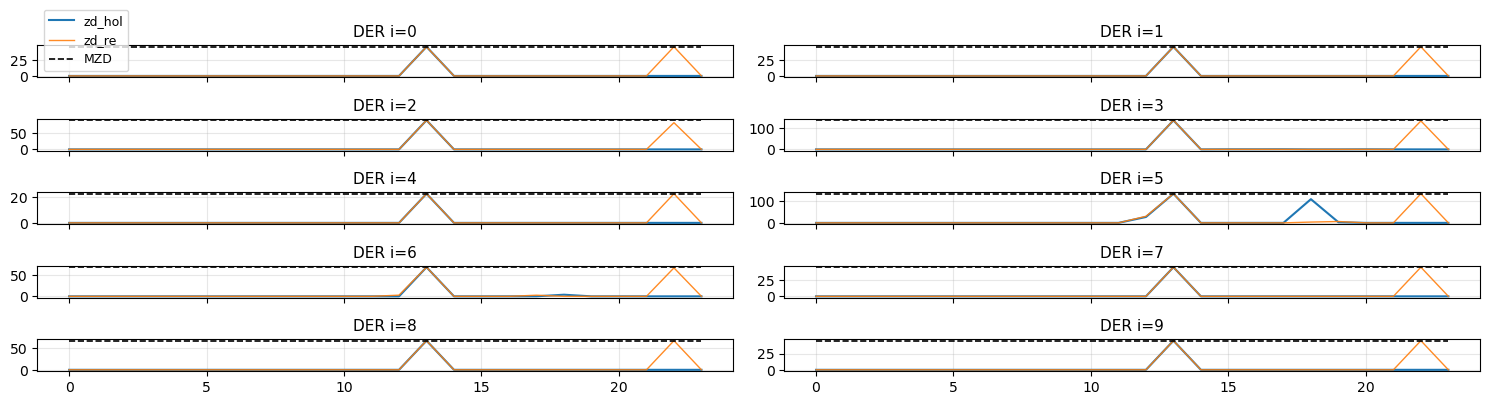

In [54]:
scen = 0 

fig, axes = plt.subplots(5, 2, figsize=(15, 4), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)

for idx, i in enumerate(range(I)):
    ax = axes[idx]
    # ax.plot(t_idx, zd_ind[i, :, scen], linewidth=1, label='zd_ind', alpha=0.9)
    ax.plot(t_idx, zd_hol[i, :, scen], linewidth=1.5, label='zd_hol', alpha=1)
    ax.plot(t_idx, zd_re[i, :, scen], linewidth=1, label='zd_re', alpha=0.9)
    ax.plot(t_idx, MZD[i, :, scen], linestyle='--', color='black', linewidth=1.2, label='MZD')
    
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [55]:
print("="*50) ; print("AGGREGATOR LOSS ANALYSIS") ; print("="*50)
total_losses = []
for t in range(T):
    scenario_losses = []
    
    for s in range(S):
        total_supply = np.sum(dp_re[:, t, s])
        total_demand = np.sum(dm_re[:, t, s])
        lambda_price = -lambda_rep[t, s] * S
        
        loss = (total_demand - total_supply) * (lambda_price - P_RT[t, s])
        scenario_losses.append(loss)
    
    avg_loss = np.mean(scenario_losses)
    total_losses.append(avg_loss)
overall_avg_loss = np.mean(total_losses)
total_loss = np.sum(total_losses)
print("Individual Participation Profit", OBJ_IND)
print("Expected Replay Profit", OBJ_RE)
print(f"Total loss across all time periods: {total_loss:.2f}")
print("Realized Profit", OBJ_RE + total_loss)
print("Holistic Profit", OBJ_HOL)
print(); print("="*60) ; print("INDIVIDUAL PROFIT ANALYSIS") ; print("="*60)
profit_ind = np.zeros(I) ; profit_re = np.zeros(I) ; profit_hol = np.zeros(I) ; profit_re_adjusted = np.zeros(I)

price_weighted_usage = np.zeros(I)
for i, t, s in product(range(I), range(T), range(S)):
        lambda_price = -lambda_rep[t, s] * S
        dm_contribution = dm_re[i, t, s] * (lambda_price)
        dp_contribution = dp_re[i, t, s] * (lambda_price)
        price_weighted_usage[i] += dm_contribution + dp_contribution

total_price_weighted_usage = np.sum(price_weighted_usage)
print(f"Total price-weighted usage: {total_price_weighted_usage:.2f}")

for i in range(I):
    profit_ind[i] = 0
    for t in range(T):
        profit_ind[i] += P_DA[t] * x_ind[i, t]
        profit_ind[i] += np.mean([P_RT[t, s] * yp_ind[i, t, s] for s in range(S)])
        profit_ind[i] -= np.mean([P_PN[t, s] * ym_ind[i, t, s] for s in range(S)])
    
    profit_re[i] = 0
    for t in range(T):
        profit_re[i] += P_DA[t] * x_re[i, t]
        profit_re[i] += np.mean([P_RT[t, s] * yp_re[i, t, s] for s in range(S)])
        profit_re[i] -= np.mean([P_PN[t, s] * ym_re[i, t, s] for s in range(S)])
        lambda_price = -lambda_rep[t, :] * S
        profit_re[i] += np.mean([lambda_price[s] * dp_re[i, t, s] for s in range(S)])
        profit_re[i] -= np.mean([lambda_price[s] * dm_re[i, t, s] for s in range(S)])
    
    profit_hol[i] = 0
    for t in range(T):
        profit_hol[i] += P_DA[t] * x_hol[i, t]
        profit_hol[i] += np.mean([P_RT[t, s] * yp_hol[i, t, s] for s in range(S)])
        profit_hol[i] -= np.mean([P_PN[t, s] * ym_hol[i, t, s] for s in range(S)])
        lambda_price = -lambda_rep[t, :] * S
        profit_hol[i] += np.mean([lambda_price[s] * dp_hol[i, t, s] for s in range(S)])
        profit_hol[i] -= np.mean([lambda_price[s] * dm_hol[i, t, s] for s in range(S)])

loss_per_player = np.zeros(I)
for i in range(I):
    if total_price_weighted_usage > 0:
        loss_per_player[i] = total_loss * (price_weighted_usage[i] / total_price_weighted_usage)
    else:
        loss_per_player[i] = total_loss / I  # fallback to equal distribution
    profit_re_adjusted[i] = profit_re[i] + loss_per_player[i]

print(f"{'Player':<8} {'Individual':<12} {'Replay':<12} {'Re+Loss':<12} {'Holistic':<12} {'Price Weight':<12} {'Loss Share':<12} {'Re+Loss-Ind (%)':<22}") # 마지막 열 이름 및 간격 수정
print("-" * 125)

# 합계 계산을 위한 변수 초기화
total_ind = 0 ; total_re = 0 ; total_hol = 0 ; total_re_adj = 0

# 플레이어별 데이터 출력
for i in range(I):
    diff_adj_ind = profit_re_adjusted[i] - profit_ind[i]
    
    # --- 백분율 계산 로직 추가 ---
    # Individual 이익이 0이 아닐 경우에만 백분율 계산
    if profit_ind[i] != 0:
        percentage_change = (diff_adj_ind / profit_ind[i]) * 100
        # 포맷팅: 소수점 한 자리까지, 항상 부호(+) 표시
        final_column_str = f"{diff_adj_ind:<12.2f} ({percentage_change:+.1f}%)"
    else:
        # Individual 이익이 0일 경우 'N/A' 또는 'inf'로 표시
        final_column_str = f"{diff_adj_ind:<12.2f} (N/A)"
    # --- 여기까지 ---

    print(f"{i:<8} {profit_ind[i]:<12.2f} {profit_re[i]:<12.2f} {profit_re_adjusted[i]:<12.2f} {profit_hol[i]:<12.2f} {loss_per_player[i]:<12.2f} {final_column_str:<22}")
    
    # 합계 누적
    total_ind += profit_ind[i]
    total_re += profit_re[i]
    total_hol += profit_hol[i]
    total_re_adj += profit_re_adjusted[i]

# 전체 합계에 대한 차이 및 백분율 계산
total_diff_adj_ind = total_re_adj - total_ind
if total_ind != 0:
    total_percentage_change = (total_diff_adj_ind / total_ind) * 100
    total_final_column_str = f"{total_diff_adj_ind:<12.2f} ({total_percentage_change:+.1f}%)"
else:
    total_final_column_str = f"{total_diff_adj_ind:<12.2f} (N/A)"
    
print("-" * 125)
print(f"{'TOTAL':<8} {total_ind:<12.2f} {total_re:<12.2f} {total_re_adj:<12.2f} {total_hol:<12.2f} {np.sum(loss_per_player):<12.2f} {total_final_column_str:<22}")

# =======================================
# ⬇️ DataFrame으로 정리
# =======================================
results = []
for i in range(I):
    diff_adj_ind = profit_re_adjusted[i] - profit_ind[i]
    if profit_ind[i] != 0:
        percentage_change = (diff_adj_ind / profit_ind[i]) * 100
    else:
        percentage_change = np.nan  # 0 나눗셈 방지

    results.append({
        "Player": i,
        "Individual Profit": profit_ind[i],
        "Replay Profit": profit_re[i],
        "Replay + Loss": profit_re_adjusted[i],
        "Holistic Profit": profit_hol[i],
        "Loss Share": loss_per_player[i],
        "Replay+Loss - Individual": diff_adj_ind,
        "Change (%)": percentage_change
    })

results.append({
    "Player": "TOTAL",
    "Individual Profit": np.sum(profit_ind),
    "Replay Profit": np.sum(profit_re),
    "Replay + Loss": np.sum(profit_re_adjusted),
    "Holistic Profit": np.sum(profit_hol),
    "Loss Share": np.sum(loss_per_player),
    "Replay+Loss - Individual": np.sum(profit_re_adjusted) - np.sum(profit_ind),
    "Change (%)": (np.sum(profit_re_adjusted) - np.sum(profit_ind)) / np.sum(profit_ind) * 100 if np.sum(profit_ind) != 0 else np.nan
})

df_result = pd.DataFrame(results)

# =======================================
# ⬇️ CSV 저장 경로 설정
# =======================================
output_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\symply\DER\solution"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"profit_analysis_{SEED}.csv")

df_result.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\n✅ 결과가 CSV로 저장되었습니다: {output_path}")

AGGREGATOR LOSS ANALYSIS
Individual Participation Profit 4360397.97362542
Expected Replay Profit 5306039.38015792
Total loss across all time periods: -1656776.62
Realized Profit 3649262.761462726
Holistic Profit 5223532.87954944

INDIVIDUAL PROFIT ANALYSIS
Total price-weighted usage: 161593954.97
Player   Individual   Replay       Re+Loss      Holistic     Price Weight Loss Share   Re+Loss-Ind (%)       
-----------------------------------------------------------------------------------------------------------------------------
0        296760.95    355682.92    256092.10    349567.92    -99590.82    -40668.85    (-13.7%) 
1        384630.00    456870.03    331249.46    451039.04    -125620.57   -53380.54    (-13.9%) 
2        537916.93    655019.32    435872.64    645232.48    -219146.68   -102044.29   (-19.0%) 
3        744065.71    899660.18    596275.37    884255.12    -303384.80   -147790.33   (-19.9%) 
4        207085.29    272704.47    176437.33    269987.90    -96267.14    -306

In [56]:
print("="*80) ; print("DETAILED AGGREGATOR LOSS DEBUGGING") ; print("="*80)

total_losses = [] ; detailed_results = []

for t in range(T):
    scenario_losses = [] ; scenario_details = []
    
    for s in range(S):
        total_supply = np.sum(dp_re[:, t, s]) ; total_demand = np.sum(dm_re[:, t, s])
        lambda_price = -lambda_rep[t, s] * S ; rt_price = P_RT[t, s]
        
        imbalance = total_demand - total_supply ; price_diff = lambda_price - rt_price 
        loss = imbalance * price_diff
        
        if imbalance > 0: scenario_type = "Excess Demand"
        elif imbalance < 0: scenario_type = "Excess Supply"
        else: scenario_type = "Balanced"
        
        detail = {
            't': t, 's': s,
            'total_demand': total_demand,
            'total_supply': total_supply,
            'imbalance': imbalance,
            'lambda_price': lambda_price,
            'rt_price': rt_price,
            'price_diff': price_diff,
            'loss': loss,
            'scenario_type': scenario_type
        }
        
        scenario_losses.append(loss) ; scenario_details.append(detail)
    
    avg_loss = np.mean(scenario_losses) ; total_losses.append(avg_loss) ; detailed_results.extend(scenario_details)

total_loss = np.sum(total_losses) ; print(f"TOTAL LOSS: {total_loss:.2f}")
print(f"Average loss per period: {np.mean(total_losses):.2f}") ; print()

TARGET_TIMES = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19, 20, 21, 22,23]

if TARGET_TIMES is not None: display_periods = TARGET_TIMES ; print(f"DETAILED BREAKDOWN (Time periods: {TARGET_TIMES}):")
print("-" * 120) ; print(f"{'t':<3} {'s':<3} {'Demand':<8} {'Supply':<8} {'Imbal':<8} {'Lambda':<8} {'RT':<8} {'L-RT':<8} {'Loss':<10} {'Type':<15}") ; print("-" * 120)

for detail in detailed_results:
    if detail['t'] in display_periods:
        print(f"{detail['t']:<3} {detail['s']:<3} {detail['total_demand']:<8.2f} {detail['total_supply']:<8.2f} "
              f"{detail['imbalance']:<8.2f} {detail['lambda_price']:<8.2f} {detail['rt_price']:<8.2f} "
              f"{detail['price_diff']:<8.2f} {detail['loss']:<10.2f} {detail['scenario_type']:<15}")
print()

excess_demand_losses = [d['loss'] for d in detailed_results if d['scenario_type'] == 'Excess Demand']
excess_supply_losses = [d['loss'] for d in detailed_results if d['scenario_type'] == 'Excess Supply']
balanced_losses = [d['loss'] for d in detailed_results if d['scenario_type'] == 'Balanced']

print("LOSS BY SCENARIO TYPE:")
print(f"Excess Demand scenarios: {len(excess_demand_losses)} cases, Total loss: {sum(excess_demand_losses):.2f}")
print(f"Excess Supply scenarios: {len(excess_supply_losses)} cases, Total loss: {sum(excess_supply_losses):.2f}")
print(f"Balanced scenarios: {len(balanced_losses)} cases, Total loss: {sum(balanced_losses):.2f}")
print()

lambda_gt_rt_count = sum(1 for d in detailed_results if d['price_diff'] > 0.001)
lambda_lt_rt_count = sum(1 for d in detailed_results if d['price_diff'] < -0.001)
lambda_eq_rt_count = sum(1 for d in detailed_results if abs(d['price_diff']) < 0.001)

print("PRICE RELATIONSHIP ANALYSIS:")
print(f"Lambda > RT: {lambda_gt_rt_count} cases ({lambda_gt_rt_count/(T*S)*100:.1f}%)")
print(f"Lambda < RT: {lambda_lt_rt_count} cases ({lambda_lt_rt_count/(T*S)*100:.1f}%)")
print(f"Lambda ≈ RT: {lambda_eq_rt_count} cases ({lambda_eq_rt_count/(T*S)*100:.1f}%)")

print("\nLOSS BY TIME PERIOD:")
for t in range(T): 
    period_losses = [d['loss'] for d in detailed_results if d['t'] == t]
    avg_period_loss = np.mean(period_losses)
    print(f"t={t}: Average loss = {avg_period_loss:.2f}")

DETAILED AGGREGATOR LOSS DEBUGGING
TOTAL LOSS: -1656776.62
Average loss per period: -69032.36

DETAILED BREAKDOWN (Time periods: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]):
------------------------------------------------------------------------------------------------------------------------
t   s   Demand   Supply   Imbal    Lambda   RT       L-RT     Loss       Type           
------------------------------------------------------------------------------------------------------------------------
0   0   0.00     0.00     0.00     399.20   54.49    344.71   0.00       Balanced       
0   1   0.00     0.00     0.00     506.44   64.93    441.52   0.00       Balanced       
0   2   0.00     0.00     0.00     271.21   40.15    231.07   0.00       Balanced       
0   3   0.00     0.00     0.00     451.62   50.54    401.07   0.00       Balanced       
0   4   0.00     0.00     0.00     185.94   45.19    140.75   0.00       Balanced       
0   5 

In [57]:
print("="*100) ; print("INDIVIDUAL vs REPLAY PROFIT COMPONENT COMPARISON") ; print("="*100)

components = ['DA_Market', 'RT_Market', 'Penalty', 'Pool_Supply', 'Pool_Demand']
profit_ind_comp = {comp: np.zeros(I) for comp in components}
profit_re_comp = {comp: np.zeros(I) for comp in components}

for i in range(I):
    for t in range(T):
        profit_ind_comp['DA_Market'][i] += P_DA[t] * x_ind[i, t]
    for t in range(T):
        profit_ind_comp['RT_Market'][i] += np.mean([P_RT[t, s] * yp_ind[i, t, s] for s in range(S)])
    for t in range(T):
        profit_ind_comp['Penalty'][i] -= np.mean([P_PN[t, s] * ym_ind[i, t, s] for s in range(S)])
    profit_ind_comp['Pool_Supply'][i] = 0
    profit_ind_comp['Pool_Demand'][i] = 0

for i in range(I):
    for t in range(T):
        profit_re_comp['DA_Market'][i] += P_DA[t] * x_re[i, t]
    for t in range(T):
        profit_re_comp['RT_Market'][i] += np.mean([P_RT[t, s] * yp_re[i, t, s] for s in range(S)])
    for t in range(T):
        profit_re_comp['Penalty'][i] -= np.mean([P_PN[t, s] * ym_re[i, t, s] for s in range(S)])
    for t in range(T):
        lambda_price = -lambda_rep[t, :] * S
        profit_re_comp['Pool_Supply'][i] += np.mean([lambda_price[s] * dp_re[i, t, s] for s in range(S)])
    for t in range(T):
        lambda_price = -lambda_rep[t, :] * S
        profit_re_comp['Pool_Demand'][i] -= np.mean([lambda_price[s] * dm_re[i, t, s] for s in range(S)])

print("INDIVIDUAL PARTICIPATION COMPONENTS:")
print(f"{'Player':<8} {'DA Market':<12} {'RT Market':<12} {'Penalty':<12} {'Pool Supply':<12} {'Pool Demand':<12} {'Total':<12}")
print("-" * 85)

total_ind_comp = {comp: 0 for comp in components}
for i in range(I):
    player_total_ind = sum(profit_ind_comp[comp][i] for comp in components)
    print(f"{i:<8} {profit_ind_comp['DA_Market'][i]:<12.2f} {profit_ind_comp['RT_Market'][i]:<12.2f} "
          f"{profit_ind_comp['Penalty'][i]:<12.2f} {profit_ind_comp['Pool_Supply'][i]:<12.2f} "
          f"{profit_ind_comp['Pool_Demand'][i]:<12.2f} {player_total_ind:<12.2f}")
    
    for comp in components:
        total_ind_comp[comp] += profit_ind_comp[comp][i]

print("-" * 85)
total_ind_all = sum(total_ind_comp[comp] for comp in components)
print(f"{'TOTAL':<8} {total_ind_comp['DA_Market']:<12.2f} {total_ind_comp['RT_Market']:<12.2f} "
      f"{total_ind_comp['Penalty']:<12.2f} {total_ind_comp['Pool_Supply']:<12.2f} "
      f"{total_ind_comp['Pool_Demand']:<12.2f} {total_ind_all:<12.2f}")

print("\n" + "="*85)
print("REPLAY PARTICIPATION COMPONENTS:")
print(f"{'Player':<8} {'DA Market':<12} {'RT Market':<12} {'Penalty':<12} {'Pool Supply':<12} {'Pool Demand':<12} {'Total':<12}")
print("-" * 85)

total_re_comp = {comp: 0 for comp in components}
for i in range(I):
    player_total_re = sum(profit_re_comp[comp][i] for comp in components)
    print(f"{i:<8} {profit_re_comp['DA_Market'][i]:<12.2f} {profit_re_comp['RT_Market'][i]:<12.2f} "
          f"{profit_re_comp['Penalty'][i]:<12.2f} {profit_re_comp['Pool_Supply'][i]:<12.2f} "
          f"{profit_re_comp['Pool_Demand'][i]:<12.2f} {player_total_re:<12.2f}")
    
    for comp in components:
        total_re_comp[comp] += profit_re_comp[comp][i]

print("-" * 85)
total_re_all = sum(total_re_comp[comp] for comp in components)
print(f"{'TOTAL':<8} {total_re_comp['DA_Market']:<12.2f} {total_re_comp['RT_Market']:<12.2f} "
      f"{total_re_comp['Penalty']:<12.2f} {total_re_comp['Pool_Supply']:<12.2f} "
      f"{total_re_comp['Pool_Demand']:<12.2f} {total_re_all:<12.2f}")

# Difference analysis
print("\n" + "="*85)
print("DIFFERENCE (REPLAY - INDIVIDUAL):")
print(f"{'Player':<8} {'DA Market':<12} {'RT Market':<12} {'Penalty':<12} {'Pool Supply':<12} {'Pool Demand':<12} {'Total':<12}")
print("-" * 85)

for i in range(I):
    diff_da = profit_re_comp['DA_Market'][i] - profit_ind_comp['DA_Market'][i]
    diff_rt = profit_re_comp['RT_Market'][i] - profit_ind_comp['RT_Market'][i]
    diff_penalty = profit_re_comp['Penalty'][i] - profit_ind_comp['Penalty'][i]
    diff_pool_supply = profit_re_comp['Pool_Supply'][i] - profit_ind_comp['Pool_Supply'][i]
    diff_pool_demand = profit_re_comp['Pool_Demand'][i] - profit_ind_comp['Pool_Demand'][i]
    diff_total = diff_da + diff_rt + diff_penalty + diff_pool_supply + diff_pool_demand
    
    print(f"{i:<8} {diff_da:<12.2f} {diff_rt:<12.2f} {diff_penalty:<12.2f} "
          f"{diff_pool_supply:<12.2f} {diff_pool_demand:<12.2f} {diff_total:<12.2f}")

print("-" * 85)
total_diff_da = total_re_comp['DA_Market'] - total_ind_comp['DA_Market']
total_diff_rt = total_re_comp['RT_Market'] - total_ind_comp['RT_Market']
total_diff_penalty = total_re_comp['Penalty'] - total_ind_comp['Penalty']
total_diff_pool_supply = total_re_comp['Pool_Supply'] - total_ind_comp['Pool_Supply']
total_diff_pool_demand = total_re_comp['Pool_Demand'] - total_ind_comp['Pool_Demand']
total_diff_all = total_re_all - total_ind_all

print(f"{'TOTAL':<8} {total_diff_da:<12.2f} {total_diff_rt:<12.2f} {total_diff_penalty:<12.2f} "
      f"{total_diff_pool_supply:<12.2f} {total_diff_pool_demand:<12.2f} {total_diff_all:<12.2f}")

# Summary analysis
print("\n" + "="*60)
print("[AGGREGATION BENEFIT ANALYSIS]")
print("="*60)
print(f"Total Individual Profit:     {total_ind_all:.2f}")
print(f"Total Replay Profit:         {total_re_all:.2f}")
print(f"Aggregation Benefit:         {total_diff_all:.2f}")
print(f"Benefit Percentage:          {(total_diff_all/total_ind_all)*100:.2f}%")

print(f"\nComponent-wise Benefits:")
print(f"DA Market Change:            {total_diff_da:.2f}")
print(f"RT Market Change:            {total_diff_rt:.2f}")
print(f"Penalty Reduction:           {total_diff_penalty:.2f}")
print(f"Pool Supply Revenue:         {total_diff_pool_supply:.2f}")
print(f"Pool Demand Cost:            {total_diff_pool_demand:.2f}")
print(f"Net Pool Benefit:            {total_diff_pool_supply + total_diff_pool_demand:.2f}")

# Verification
print(f"\n[VERIFICATION]")
print(f"Expected Individual Total:   {OBJ_IND:.2f}")
print(f"Expected Replay Total:       {OBJ_RE:.2f}")
print(f"Calculated Individual Total: {total_ind_all:.2f}")
print(f"Calculated Replay Total:     {total_re_all:.2f}")

INDIVIDUAL vs REPLAY PROFIT COMPONENT COMPARISON
INDIVIDUAL PARTICIPATION COMPONENTS:
Player   DA Market    RT Market    Penalty      Pool Supply  Pool Demand  Total       
-------------------------------------------------------------------------------------
0        181980.58    155235.75    -40455.38    0.00         0.00         296760.95   
1        214321.74    231755.06    -61446.80    0.00         0.00         384630.00   
2        441279.71    225818.31    -129181.09   0.00         0.00         537916.93   
3        575569.14    338416.28    -169919.72   0.00         0.00         744065.71   
4        201336.58    77049.46     -71300.75    0.00         0.00         207085.29   
5        656652.30    403595.62    -238427.13   0.00         0.00         821820.79   
6        293242.88    176616.82    -75187.53    0.00         0.00         394672.16   
7        245569.52    134813.89    -69479.59    0.00         0.00         310903.82   
8        329169.04    188707.56    -98960.93 

In [58]:
# [VERIFICATION] (기존 코드)
print(f"\n[VERIFICATION]")
print(f"Expected Individual Total:   {OBJ_IND:.2f}")
print(f"Expected Replay Total:       {OBJ_RE:.2f}")
print(f"Calculated Individual Total: {total_ind_all:.2f}")
print(f"Calculated Replay Total:     {total_re_all:.2f}")

# --- (새로 추가) Holistic 구성요소 계산 ---
print("\n" + "="*85)
print("CALCULATING HOLISTIC COMPONENTS (for final table):")

# 'components' 변수는 이전에 정의된 ['DA_Market', 'RT_Market', 'Penalty', 'Pool_Supply', 'Pool_Demand']를 사용합니다.
total_hol_comp = {comp: 0 for comp in components} 

for i in range(I):
    for t in range(T):
        total_hol_comp['DA_Market'] += P_DA[t] * x_hol[i, t]
        
for i in range(I):
    for t in range(T):
        total_hol_comp['RT_Market'] += np.mean([P_RT[t, s] * yp_hol[i, t, s] for s in range(S)])
        
for i in range(I):
    for t in range(T):
        total_hol_comp['Penalty'] -= np.mean([P_PN[t, s] * ym_hol[i, t, s] for s in range(S)])

# Holistic 모델의 *외부* 목적함수 관점에서 Pool과 Loss는 0입니다.
total_hol_comp['Pool_Supply'] = 0
total_hol_comp['Pool_Demand'] = 0
total_hol_comp_sum = sum(total_hol_comp.values())

print(f"Calculated Holistic DA:      {total_hol_comp['DA_Market']:.2f}")
print(f"Calculated Holistic RT:      {total_hol_comp['RT_Market']:.2f}")
print(f"Calculated Holistic Penalty: {total_hol_comp['Penalty']:.2f}")
print(f"Calculated Holistic Total:   {total_hol_comp_sum:.2f}")
print(f"Original Holistic OBJ_HOL:   {OBJ_HOL:.2f}")
print("="*85)
# --- (여기까지 추가) ---


# Profit Component Summary Table
import pandas as pd
import numpy as np

# 기존 계산된 값들 사용 (total_ind_comp, total_re_comp, total_loss)
# Individual vs Replay 차이 계산
total_diff_da = total_re_comp['DA_Market'] - total_ind_comp['DA_Market']
total_diff_penalty = total_re_comp['Penalty'] - total_ind_comp['Penalty']
total_diff_rt = total_re_comp['RT_Market'] - total_ind_comp['RT_Market']
total_pool = total_re_comp['Pool_Supply'] + total_re_comp['Pool_Demand']

# Holistic 구성요소
da_hol = total_hol_comp['DA_Market']
penalty_hol = total_hol_comp['Penalty']
rt_hol = total_hol_comp['RT_Market']
pool_hol = 0  # By definition
loss_hol = 0  # By definition
total_hol = da_hol + penalty_hol + rt_hol

# 요약 테이블 생성 (수정됨: Holistic 행 추가)
summary_data = {
    'Scenario': ['Individual', 'Replay', 'Holistic', 'Replay-Ind Diff'],
    'DA': [
        total_ind_comp['DA_Market'],
        total_re_comp['DA_Market'], 
        da_hol,
        total_diff_da
    ],
    'Penalty': [
        total_ind_comp['Penalty'],
        total_re_comp['Penalty'],
        penalty_hol,
        total_diff_penalty
    ],
    'Real-time': [
        total_ind_comp['RT_Market'],
        total_re_comp['RT_Market'],
        rt_hol,
        total_diff_rt
    ],
    'Pool': [
        0,  # Individual에는 pool 없음
        total_pool,
        pool_hol,
        total_pool
    ],
    'Loss': [
        0,  # Individual에는 loss 없음
        total_loss,
        loss_hol,
        total_loss
    ],
    'Total': [
        sum(total_ind_comp[comp] for comp in ['DA_Market', 'RT_Market', 'Penalty']),
        sum(total_re_comp[comp] for comp in ['DA_Market', 'RT_Market', 'Penalty']) + total_pool + total_loss,
        total_hol,
        total_diff_da + total_diff_penalty + total_diff_rt + total_pool + total_loss
    ]
}

# DataFrame 생성
df_summary = pd.DataFrame(summary_data)

# 소수점 2자리로 반올림
for col in ['DA', 'Penalty', 'Real-time', 'Pool', 'Loss', 'Total']:
    df_summary[col] = df_summary[col].round(2)

print("="*80)
print("PROFIT COMPONENT SUMMARY TABLE (Full)")
print("="*80)
print(df_summary.to_string(index=False))

# --- (요청하신 구성의) 요약 테이블 생성 ---

# 1. Individual 값 계산
da_ind = total_ind_comp['DA_Market']
pen_ind = total_ind_comp['Penalty']
rt_pool_ind = total_ind_comp['RT_Market'] # Pool = 0
loss_ind = 0
total_ind_new = da_ind + pen_ind + rt_pool_ind + loss_ind

# 2. Replay 값 계산
da_re = total_re_comp['DA_Market']
pen_re = total_re_comp['Penalty']
rt_pool_re = total_re_comp['RT_Market'] + total_pool # RT profit + Pool profit
loss_re = total_loss
total_re_new = da_re + pen_re + rt_pool_re + loss_re # Realized Profit (OBJ_RE + total_loss)

# 3. Holistic 값 계산
da_hol = total_hol_comp['DA_Market']
pen_hol = total_hol_comp['Penalty']
rt_pool_hol = total_hol_comp['RT_Market'] # Pool = 0
loss_hol = 0
total_hol_new = da_hol + pen_hol + rt_pool_hol + loss_hol # OBJ_HOL

# 4. Difference (Replay - Individual) 값 계산
da_diff = da_re - da_ind
pen_diff = pen_re - pen_ind
rt_pool_diff = rt_pool_re - rt_pool_ind
loss_diff = loss_re - loss_ind
total_diff_new = total_re_new - total_ind_new

# 새 summary_data 딕셔너리 생성
summary_data_new = {
    'Scenario': ['Individual', 'Replay', 'Holistic', 'Replay-Ind Diff'],
    'DA': [da_ind, da_re, da_hol, da_diff],
    'RT+Pool': [rt_pool_ind, rt_pool_re, rt_pool_hol, rt_pool_diff],
    'Penalty': [pen_ind, pen_re, pen_hol, pen_diff],
    'Loss': [loss_ind, loss_re, loss_hol, loss_diff],
    'Total': [total_ind_new, total_re_new, total_hol_new, total_diff_new]
}

# DataFrame 생성
df_summary_new = pd.DataFrame(summary_data_new)

# 소수점 2자리로 반올림
for col in ['DA', 'Penalty', 'RT+Pool', 'Loss', 'Total']:
    df_summary_new[col] = df_summary_new[col].round(2)

print("="*80) # 구분선 길이
print("PROFIT COMPONENT SUMMARY TABLE (New Condensed)")
print("="*80) # 구분선 길이
print(df_summary_new.to_string(index=False))


[VERIFICATION]
Expected Individual Total:   4360397.97
Expected Replay Total:       5306039.38
Calculated Individual Total: 4360397.97
Calculated Replay Total:     5306039.38

CALCULATING HOLISTIC COMPONENTS (for final table):
Calculated Holistic DA:      3889632.88
Calculated Holistic RT:      1731431.65
Calculated Holistic Penalty: -397531.66
Calculated Holistic Total:   5223532.88
Original Holistic OBJ_HOL:   5223532.88
PROFIT COMPONENT SUMMARY TABLE (Full)
       Scenario           DA      Penalty   Real-time        Pool         Loss       Total
     Individual  3328048.380 -1015484.100 2047833.700       0.000        0.000 4360397.970
         Replay  1472871.480  -211125.220 1073985.410 2970307.710 -1656776.620 3649262.760
       Holistic  3889632.880  -397531.660 1731431.650       0.000        0.000 5223532.880
Replay-Ind Diff -1855176.900   804358.880 -973848.290 2970307.710 -1656776.620 -711135.210
PROFIT COMPONENT SUMMARY TABLE (New Condensed)
       Scenario           DA    

NameError: name 'UYM' is not defined

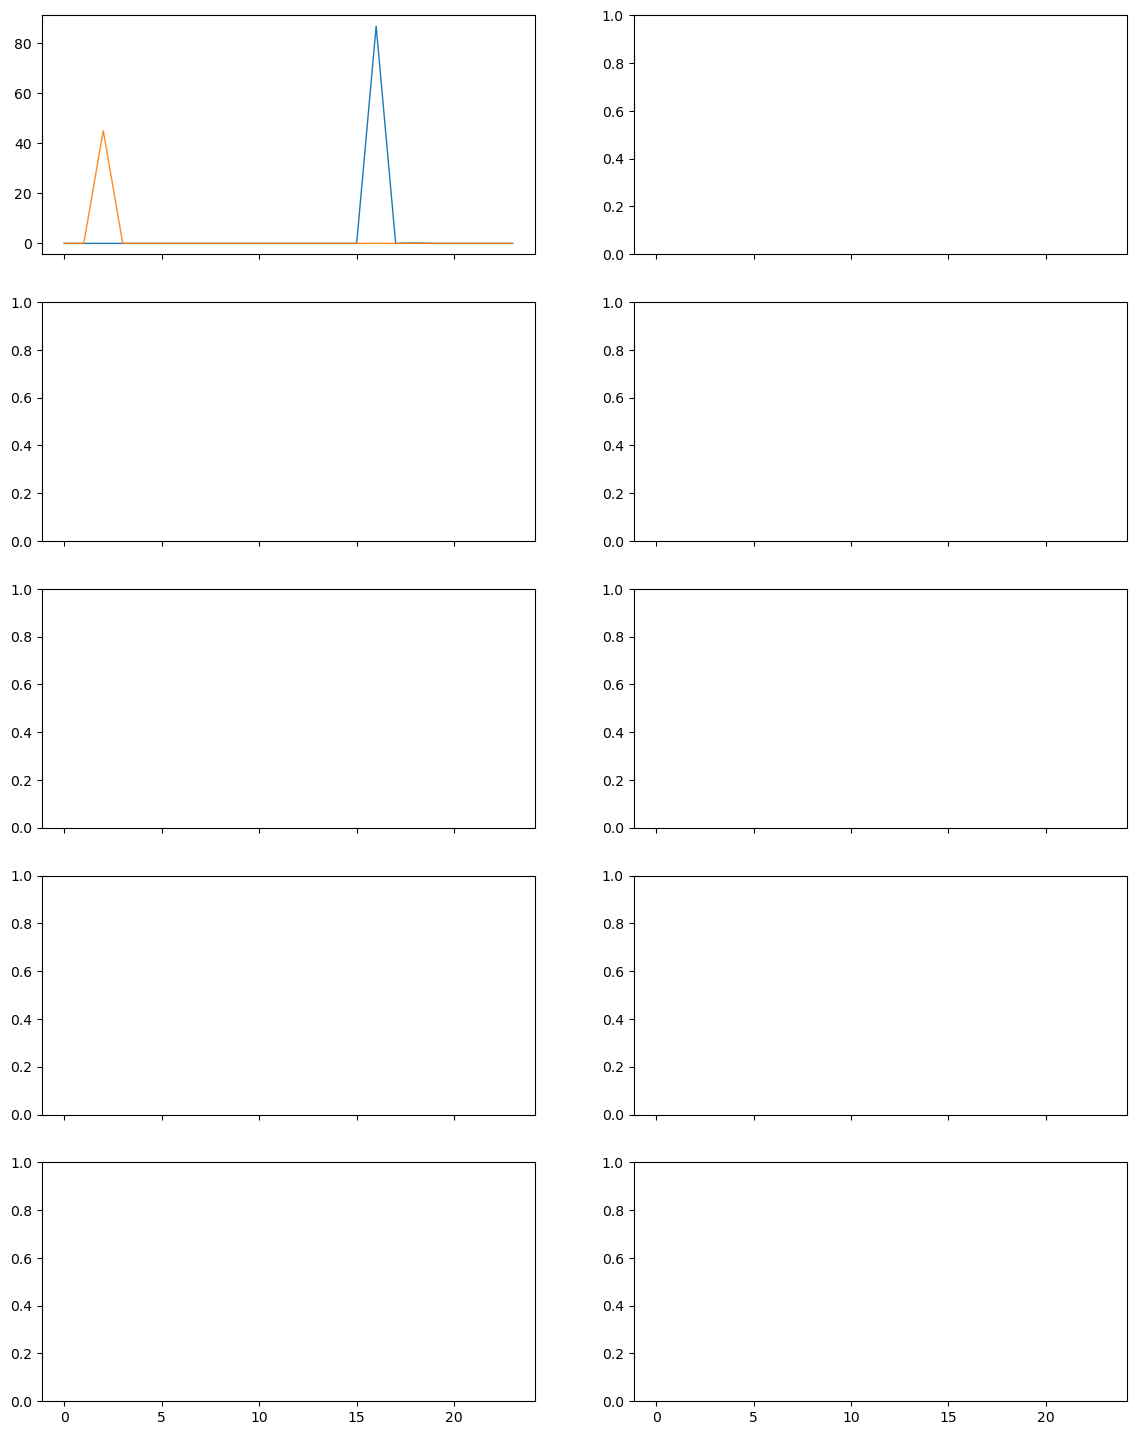

In [59]:
# === 시나리오 선택 ===
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)
R_avg = np.mean(R, axis=2)


for idx, i in enumerate(range(10)):
    ax = axes[idx]
    # ax.plot(t_idx, ym_ind[i, :, s], linewidth=1, label='ind(ym)', alpha=0.9)
    ax.plot(t_idx, ym_hol[i, :, s], linewidth=1, label='hol(ym+dm)', alpha=1)
    ax.plot(t_idx, ym_re[i, :, s], linewidth=1, label='re(ym+dm)', alpha=0.9)
    ax.plot(t_idx, UYM[i, :, s], color='black', linewidth=1.5, label='M')
    ax.plot(t_idx, x_hol[i, :], linewidth=1.5, label='x_hol', alpha=1, color='red')
    
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


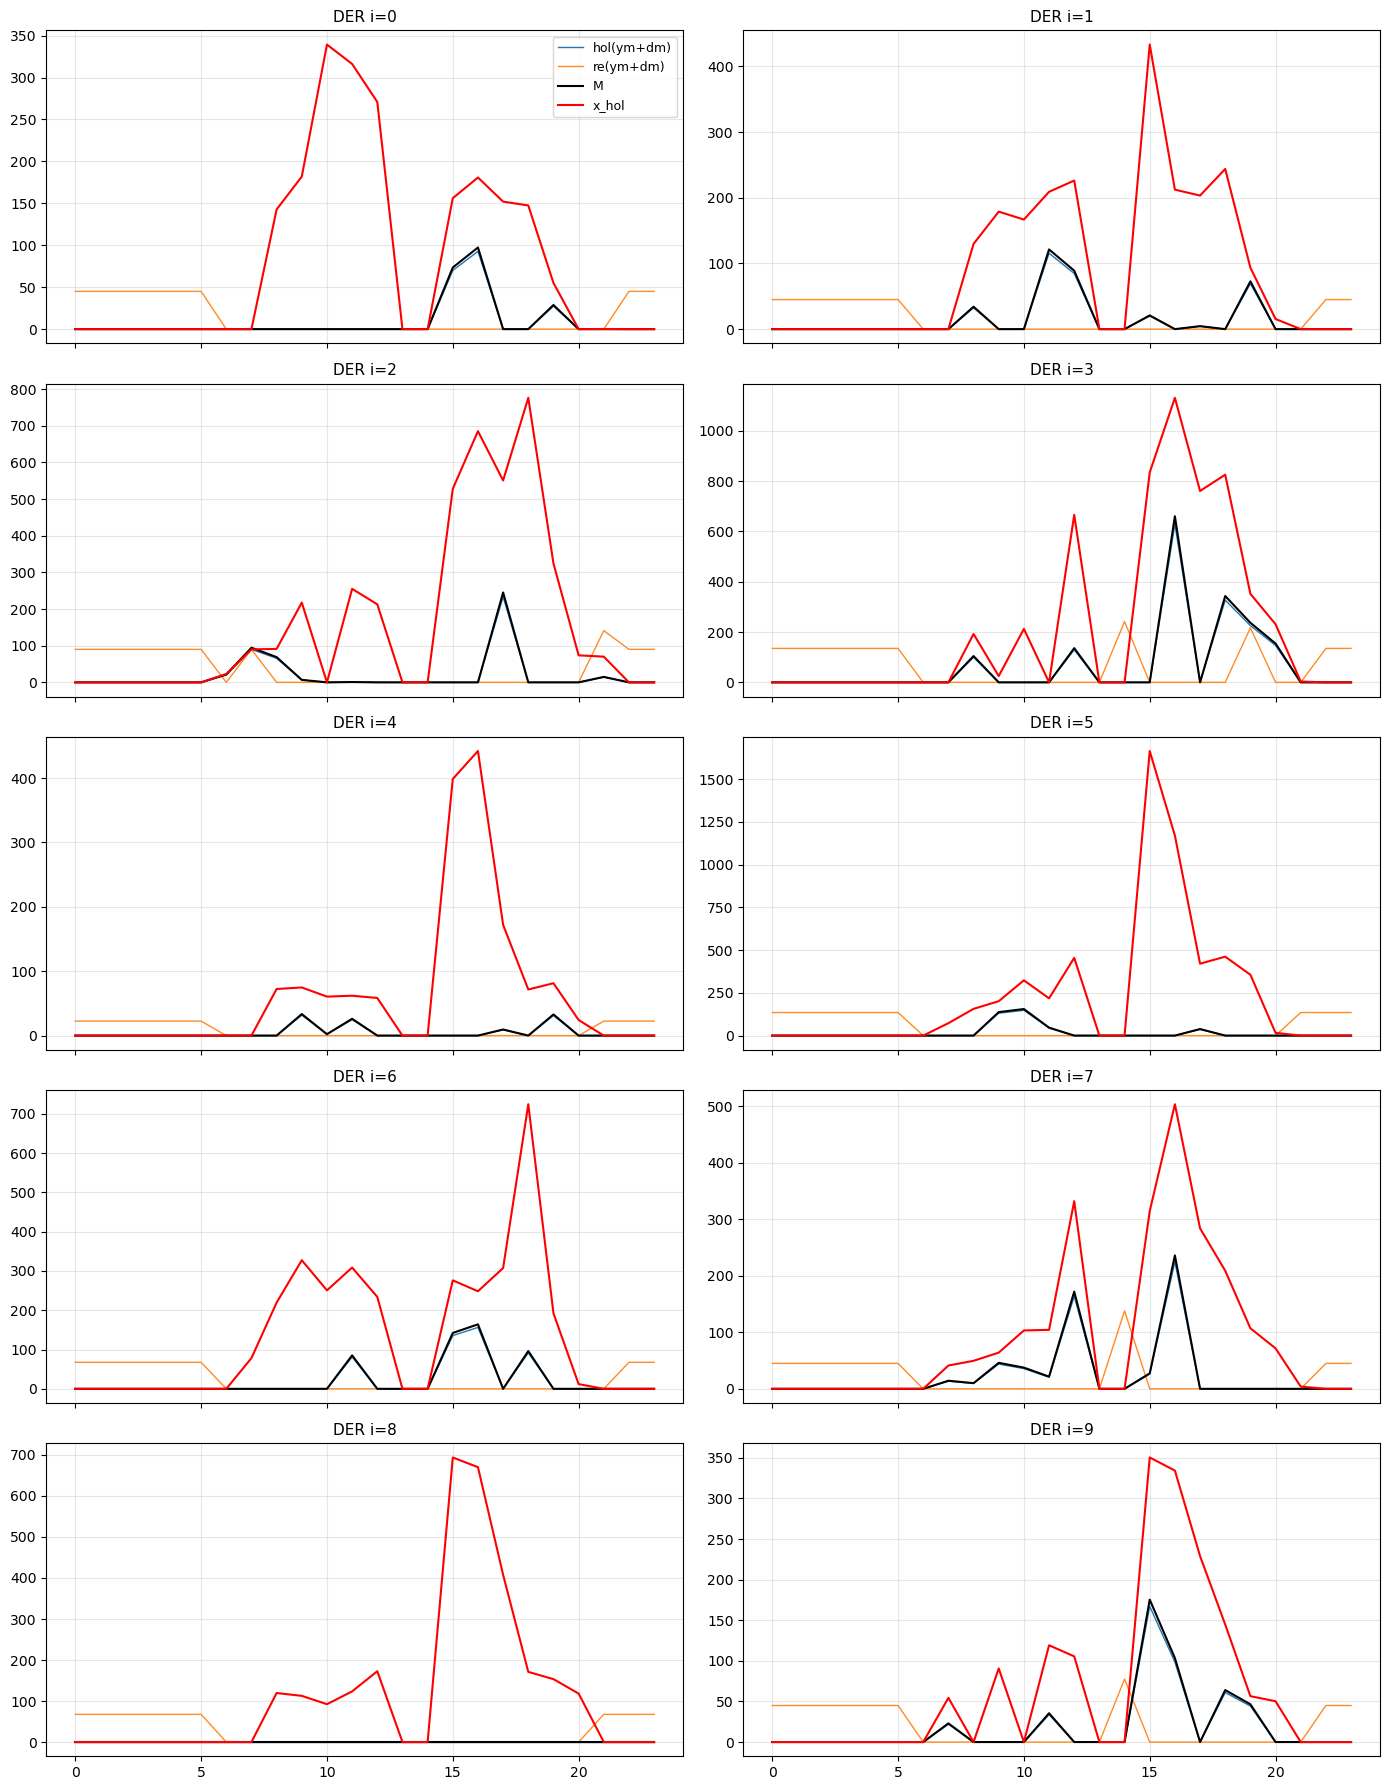

In [ ]:
# === 시나리오 선택 ===
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)
R_avg = np.mean(R, axis=2)
s=6

for idx, i in enumerate(range(10)):
    ax = axes[idx]
    # ax.plot(t_idx, ym_ind[i, :, s], linewidth=1, label='ind(ym)', alpha=0.9)
    ax.plot(t_idx, dm_hol[i, :, s], linewidth=1, label='hol(ym+dm)', alpha=1)
    ax.plot(t_idx, dm_re[i, :, s], linewidth=1, label='re(ym+dm)', alpha=0.9)
    ax.plot(t_idx, UDM[i, :, s], color='black', linewidth=1.5, label='M')
    ax.plot(t_idx, x_hol[i, :], linewidth=1.5, label='x_hol', alpha=1, color='red')
    
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
